Base path found at: d:\University\AI\SAND Project\Detecting_Dysarthia\EDA
Metadata columns: ['ID', 'Age', 'Sex', 'Class']

Found 3 example files:
 - ID000_phonationA.wav
 - ID000_phonationE.wav
 - ID000_phonationI.wav


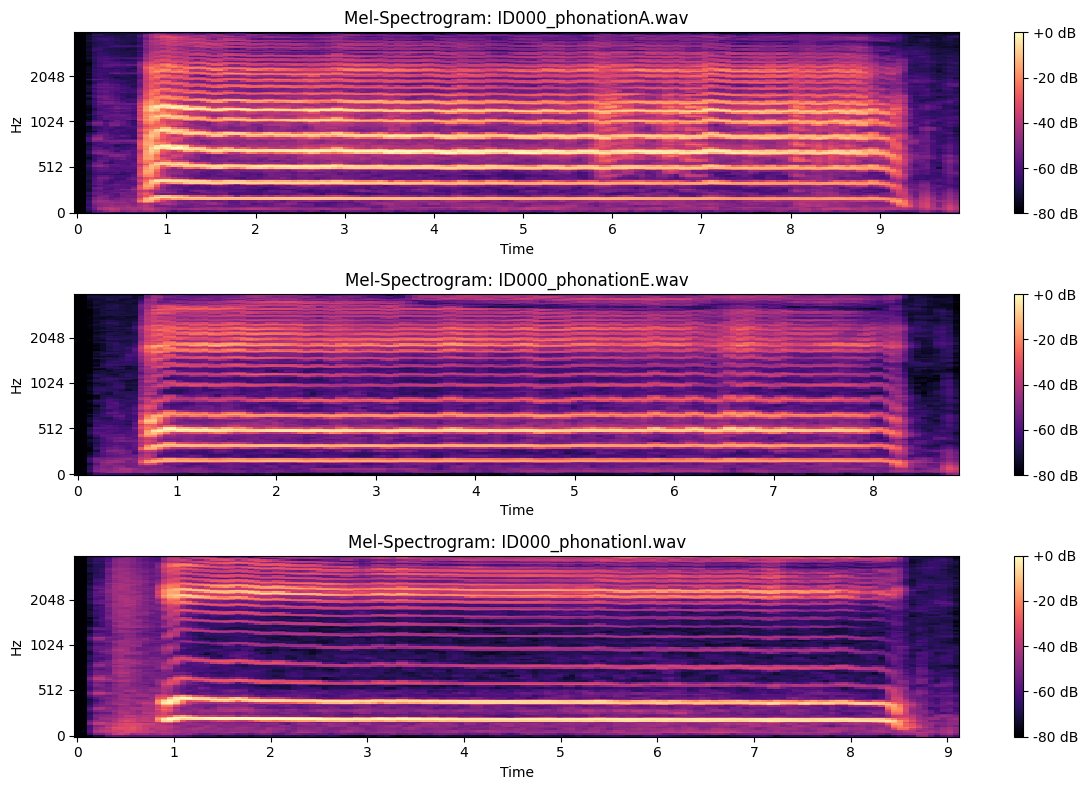

Saved: spectrogram_example.pdf
Folders found: ['phonationA', 'phonationE', 'phonationI', 'phonationO', 'phonationU', 'rhythmKA', 'rhythmPA', 'rhythmTA']

Folder 'phonationA' - sample filenames (up to 10):
    ID000_phonationA.wav
    ID001_phonationA.wav
    ID002_phonationA.wav
    ID003_phonationA.wav
    ID005_phonationA.wav
    ID006_phonationA.wav
    ID007_phonationA.wav
    ID008_phonationA.wav
    ID009_phonationA.wav
    ID010_phonationA.wav

Folder 'phonationE' - sample filenames (up to 10):
    ID000_phonationE.wav
    ID001_phonationE.wav
    ID002_phonationE.wav
    ID003_phonationE.wav
    ID005_phonationE.wav
    ID006_phonationE.wav
    ID007_phonationE.wav
    ID008_phonationE.wav
    ID009_phonationE.wav
    ID010_phonationE.wav

Folder 'phonationI' - sample filenames (up to 10):
    ID000_phonationI.wav
    ID001_phonationI.wav
    ID002_phonationI.wav
    ID003_phonationI.wav
    ID005_phonationI.wav
    ID006_phonationI.wav
    ID007_phonationI.wav
    ID008_phonat

In [1]:
# =========================================================
# Audio Feature Visualization (MFCC + Spectrogram) 
# =========================================================
import os
import re
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# -----------------------------
# Paths and dataset setup
# -----------------------------
'''
base_path = os.getcwd()  # This sets base_path to the folder where the script runs

audio_root = os.path.join(base_path, 'training_data', 'training')      # local folder named 'task1'
meta_path = os.path.join(base_path, 'training_data', 'sand_task_1.xlsx')
'''

base_path = os.getcwd()  # Folder where this notebook runs (EDA/)
project_root = os.path.abspath(os.path.join(base_path, ".."))  # Go one level up to project root

# Paths relative to project root
audio_root = os.path.join(project_root, "training_data", "training")  # training audio folder
meta_path = os.path.join(project_root, 'training_data', 'sand_task_1.xlsx')

# Load metadata
meta = pd.read_excel(meta_path)
meta['ID'] = meta['ID'].astype(str).str.strip()
print(f"Base path found at: {base_path}")
print("Metadata columns:", meta.columns.tolist())

# -----------------------------
# 1 Select example files (ensure they actually exist)
# -----------------------------
example_files = []
for folder in ['phonationA', 'phonationE', 'phonationI']:
    folder_path = os.path.join(audio_root, folder)
    if os.path.exists(folder_path):
        files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.wav')]
        if files:
            example_files.append(files[0])  # pick the first .wav file

print(f"\nFound {len(example_files)} example files:")
for f in example_files:
    print(" -", os.path.basename(f))

plots_dir = os.path.join(base_path, 'plots')
Path(plots_dir).mkdir(exist_ok=True)

# -----------------------------
# 2 Plot Spectrograms
# -----------------------------
if example_files:
    plt.figure(figsize=(12, 8))
    for i, filepath in enumerate(example_files):
        y, sr = librosa.load(filepath, sr=None)
        S = librosa.feature.melspectrogram(y=y, sr=sr)
        S_dB = librosa.power_to_db(S, ref=np.max)
        plt.subplot(len(example_files), 1, i + 1)
        librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
        plt.title(f"Mel-Spectrogram: {os.path.basename(filepath)}")
        plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'spectrogram_example.pdf'))
    plt.show()
    print("Saved: spectrogram_example.pdf")
else:
    print("No example files found for spectrograms.")

# -----------------------------
# 3 Extract MFCC features and match with metadata
# -----------------------------
# show filenames from folders (first 10 of each)
folders = sorted([d for d in os.listdir(audio_root) if os.path.isdir(os.path.join(audio_root,d))])
print("Folders found:", folders)
for f in folders:
    files = [fn for fn in os.listdir(os.path.join(audio_root,f)) if fn.lower().endswith('.wav')]
    print(f"\nFolder '{f}' - sample filenames (up to 10):")
    for fn in files[:10]:
        print("   ", fn)

# Build maps of filenames (without ext) -> full path (for all folders)
filename_map = {}
for f in folders:
    folder_path = os.path.join(audio_root, f)
    for fn in os.listdir(folder_path):
        if fn.lower().endswith('.wav'):
            key = os.path.splitext(fn)[0]
            filename_map.setdefault(key, []).append(os.path.join(folder_path, fn))

print(f"\nTotal unique filename keys found: {len(filename_map)}")

# Helpful helper to extract digit sequence from a string (if present)
def get_digits(s):
    m = re.search(r'\d+', s)
    return m.group(0) if m else None

# Matching function: tries multiple strategies and returns filepath or None
def find_file_for_id(id_str):
    id_clean = str(id_str).strip()
    # 1) exact match (case-insensitive)
    if id_clean in filename_map:
        return filename_map[id_clean][0]
    id_lower = id_clean.lower()
    for k in filename_map:
        if k.lower() == id_lower:
            return filename_map[k][0]
    # 2) strip leading zeros
    id_nozeros = id_clean.lstrip('0')
    for k in filename_map:
        if k.lstrip('0').lower() == id_nozeros.lower():
            return filename_map[k][0]
    # 3) match by digits substring (e.g., filename 'sub-001_A' -> '001')
    id_digits = get_digits(id_clean)
    if id_digits:
        for k in filename_map:
            k_digits = get_digits(k)
            if k_digits and k_digits == id_digits:
                return filename_map[k][0]
    # 4) filename contains id as substring (case-insensitive)
    for k in filename_map:
        if id_clean.lower() in k.lower():
            return filename_map[k][0]
    # 5) last resort: if id is short, try matching suffix/prefix patterns
    for k in filename_map:
        if k.lower().endswith(id_lower) or k.lower().startswith(id_lower):
            return filename_map[k][0]
    return None

# Quick test: try matching first 20 IDs and show results
sample_ids = list(meta['ID'].astype(str).head(20))
matches = {}
for sid in sample_ids:
    matches[sid] = find_file_for_id(sid)

print("\nSample matching results (first 20 IDs):")
for sid in sample_ids:
    print(sid, "->", matches[sid])

# Now attempt robust MFCC extraction using the matching function
results = []
bad_ids = []

for idx, row in meta.iterrows():
    sid = str(row['ID']).strip()
    fpath = find_file_for_id(sid)
    if fpath is None:
        bad_ids.append(sid)
        continue
    try:
        y, sr = librosa.load(fpath, sr=None)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc, axis=1)
        results.append([row['Class']] + mfcc_mean.tolist())
    except Exception as e:
        print("Error loading:", fpath, "->", e)
        bad_ids.append(sid)

print(f"\nExtracted MFCCs for {len(results)} files.")
print(f"Unmatched / failed IDs: {len(bad_ids)} (saved to unmatched_ids.csv)")

# Save unmatched for inspection
pd.DataFrame({'unmatched_ID': bad_ids}).to_csv(os.path.join(base_path, 'unmatched_ids.csv'), index=False)

# If you want to see a few unmatched IDs now:
print("First 20 unmatched IDs:", bad_ids[:20])

# Build MFCC DataFrame if any results found
if results:
    cols = ['Class'] + [f'MFCC_{i}' for i in range(1,14)]
    mfcc_df = pd.DataFrame(results, columns=cols)
    print(mfcc_df.head())
    # compute mean MFCCs per class and save plot (optional)
    mfcc_means = mfcc_df.groupby('Class').mean().T
    print("Mean MFCCs per class computed.")
else:
    print("No MFCC data was extracted. Inspect unmatched_ids.csv to find naming mismatches.")


Saved MFCC table: d:\University\AI\SAND Project\Detecting_Dysarthia\EDA\Plots\mfcc_features_table.csv


<Figure size 1000x600 with 0 Axes>

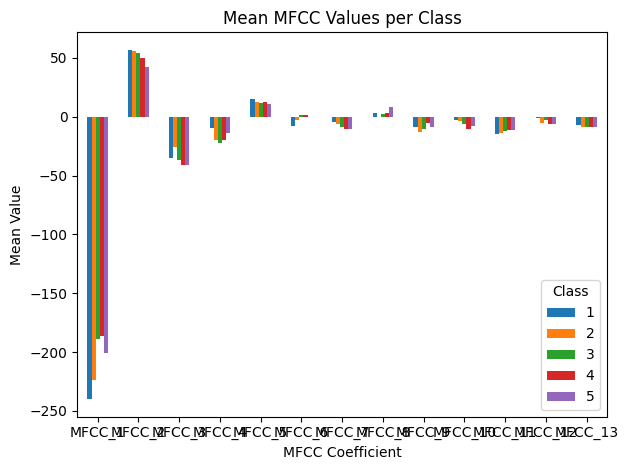

Saved MFCC figure: d:\University\AI\SAND Project\Detecting_Dysarthia\EDA\Plots\mfcc_features.pdf
Saved class counts: d:\University\AI\SAND Project\Detecting_Dysarthia\EDA\Plots\mfcc_class_counts.csv


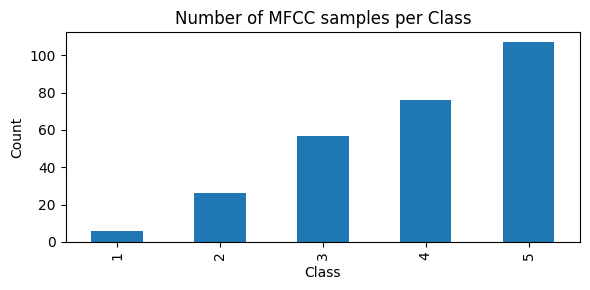

Saved class counts figure: d:\University\AI\SAND Project\Detecting_Dysarthia\EDA\Plots\mfcc_class_counts.pdf


In [2]:
# Save MFCC DataFrame and create plots (run after your previous cell)
import os
import matplotlib.pyplot as plt
plots_dir = os.path.join(base_path, "Plots") 
os.makedirs(plots_dir, exist_ok=True)

# 1) Save the full MFCC dataframe to CSV for later inspection
mfcc_csv_path = os.path.join(plots_dir, 'mfcc_features_table.csv')
mfcc_df.to_csv(mfcc_csv_path, index=False)
print("Saved MFCC table:", mfcc_csv_path)

# 2) Recreate & save mean-MFCC bar-plot (in case earlier cell did not save it)
if 'mfcc_means' not in globals():
    mfcc_means = mfcc_df.groupby('Class').mean().T

plt.figure(figsize=(10,6))
ax = mfcc_means.plot(kind='bar', rot=0)
ax.set_title("Mean MFCC Values per Class")
ax.set_xlabel("MFCC Coefficient")
ax.set_ylabel("Mean Value")
ax.legend(title="Class")
plt.tight_layout()
mfcc_plot_path = os.path.join(plots_dir, 'mfcc_features.pdf')
plt.savefig(mfcc_plot_path)
plt.show()
print("Saved MFCC figure:", mfcc_plot_path)

# 3) Save class counts and a small bar plot for quick reference
class_counts = mfcc_df['Class'].value_counts().sort_index()
class_counts_path = os.path.join(plots_dir, 'mfcc_class_counts.csv')
class_counts.to_csv(class_counts_path, header=['count'])
print("Saved class counts:", class_counts_path)

plt.figure(figsize=(6,3))
class_counts.plot(kind='bar')
plt.title("Number of MFCC samples per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
class_counts_plot = os.path.join(plots_dir, 'mfcc_class_counts.pdf')
plt.savefig(class_counts_plot)
plt.show()
print("Saved class counts figure:", class_counts_plot)


In [1]:
# =========================================================
# Audio Feature Visualization (MFCC + Spectrogram)
# =========================================================
import os
import re
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [3]:

# === SETUP ===
current_dir = os.getcwd()  # Folder where this notebook runs (EDA/)
project_root = os.path.abspath(os.path.join(current_dir, ".."))  # Go one level up to project root

# Paths relative to project root
audio_root = os.path.join(project_root, "training_data", "training")  # training audio folder
meta_path = os.path.join(project_root, "training_data", "sand_task_1.xlsx")
plots_dir = os.path.join(current_dir, "Plots")  # Save plots locally inside EDA/Plots

# Make Plots folder if it does not exist
os.makedirs(plots_dir, exist_ok=True)

# === Load metadata ===
meta = pd.read_excel(meta_path)
meta["ID"] = meta["ID"].astype(str).str.strip()
print("Metadata columns:", meta.columns.tolist())


Metadata columns: ['ID', 'Age', 'Sex', 'Class']


In [4]:
# =========================================================
# 1 Select example audio files
# =========================================================
example_files = []
for folder in ["phonationA", "phonationE", "phonationI"]:
    folder_path = os.path.join(audio_root, folder)
    if os.path.exists(folder_path):
        files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".wav")]
        if files:
            example_files.append(files[0])  # pick first available .wav file

print(f"\nFound {len(example_files)} example files for spectrograms:")
for f in example_files:
    print(" -", os.path.basename(f))


Found 3 example files for spectrograms:
 - ID000_phonationA.wav
 - ID000_phonationE.wav
 - ID000_phonationI.wav


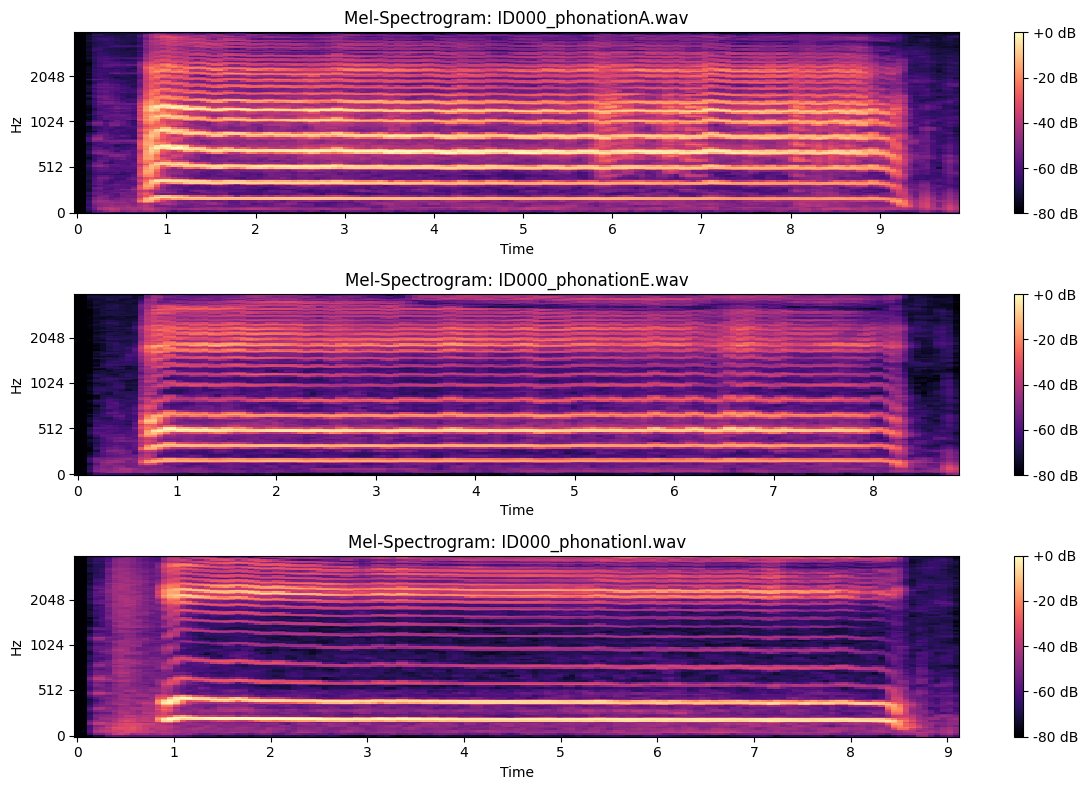

Saved: d:\University\AI\SAND Project\Detecting_Dysarthia\EDA\Plots\spectrogram_example.pdf


In [5]:
# =========================================================
# 2 Plot Mel Spectrograms
# =========================================================
if example_files:
    plt.figure(figsize=(12, 8))
    for i, filepath in enumerate(example_files):
        y, sr = librosa.load(filepath, sr=None)
        S = librosa.feature.melspectrogram(y=y, sr=sr)
        S_dB = librosa.power_to_db(S, ref=np.max)
        plt.subplot(len(example_files), 1, i + 1)
        librosa.display.specshow(S_dB, sr=sr, x_axis="time", y_axis="mel", cmap="magma")
        plt.title(f"Mel-Spectrogram: {os.path.basename(filepath)}")
        plt.colorbar(format="%+2.0f dB")
    plt.tight_layout()
    spectrogram_path = os.path.join(plots_dir, "spectrogram_example.pdf")
    plt.savefig(spectrogram_path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {spectrogram_path}")
else:
    print("No example files found for spectrograms.")

<Figure size 1000x600 with 0 Axes>

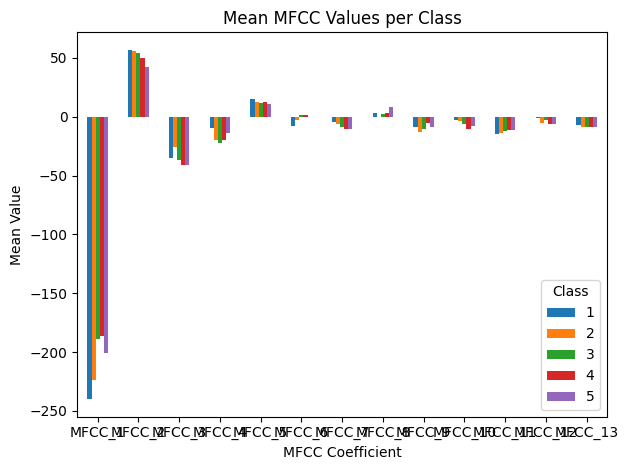

Saved: d:\University\AI\SAND Project\Detecting_Dysarthia\EDA\Plots\mfcc_features.pdf


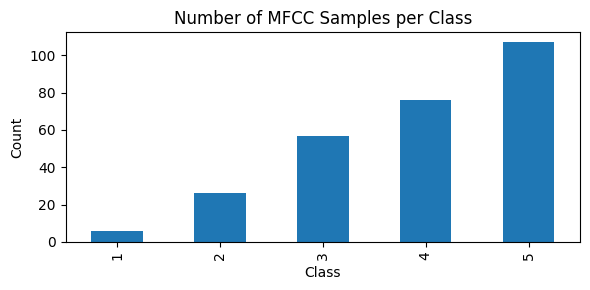

Saved: d:\University\AI\SAND Project\Detecting_Dysarthia\EDA\Plots\mfcc_class_counts.pdf


In [6]:
# =========================================================
# 3 MFCC Feature Extraction + Mean Plot
# =========================================================

# Collect folders and map filenames to paths
folders = sorted([d for d in os.listdir(audio_root) if os.path.isdir(os.path.join(audio_root, d))])
filename_map = {}
for f in folders:
    folder_path = os.path.join(audio_root, f)
    for fn in os.listdir(folder_path):
        if fn.lower().endswith(".wav"):
            key = os.path.splitext(fn)[0]
            filename_map.setdefault(key, []).append(os.path.join(folder_path, fn))

# Helper to extract digits
def get_digits(s):
    m = re.search(r"\d+", s)
    return m.group(0) if m else None

# File matching function
def find_file_for_id(id_str):
    id_clean = str(id_str).strip()
    if id_clean in filename_map:
        return filename_map[id_clean][0]
    id_lower = id_clean.lower()
    for k in filename_map:
        if k.lower() == id_lower:
            return filename_map[k][0]
    id_nozeros = id_clean.lstrip("0")
    for k in filename_map:
        if k.lstrip("0").lower() == id_nozeros.lower():
            return filename_map[k][0]
    id_digits = get_digits(id_clean)
    if id_digits:
        for k in filename_map:
            k_digits = get_digits(k)
            if k_digits and k_digits == id_digits:
                return filename_map[k][0]
    for k in filename_map:
        if id_clean.lower() in k.lower():
            return filename_map[k][0]
    for k in filename_map:
        if k.lower().endswith(id_lower) or k.lower().startswith(id_lower):
            return filename_map[k][0]
    return None

# Extract MFCC features and match with metadata
results = []
for _, row in meta.iterrows():
    sid = str(row["ID"]).strip()
    fpath = find_file_for_id(sid)
    if fpath is None:
        continue
    try:
        y, sr = librosa.load(fpath, sr=None)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc, axis=1)
        results.append([row["Class"]] + mfcc_mean.tolist())
    except Exception as e:
        print("Error loading:", fpath, "->", e)

# Build dataframe only for plotting
if results:
    cols = ["Class"] + [f"MFCC_{i}" for i in range(1, 14)]
    mfcc_df = pd.DataFrame(results, columns=cols)
    mfcc_means = mfcc_df.groupby("Class").mean().T

    # === Plot Mean MFCCs per class ===
    plt.figure(figsize=(10, 6))
    ax = mfcc_means.plot(kind="bar", rot=0)
    ax.set_title("Mean MFCC Values per Class")
    ax.set_xlabel("MFCC Coefficient")
    ax.set_ylabel("Mean Value")
    ax.legend(title="Class")
    plt.tight_layout()
    mfcc_plot_path = os.path.join(plots_dir, "mfcc_features.pdf")
    plt.savefig(mfcc_plot_path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {mfcc_plot_path}")

    # === Plot Class Counts ===
    class_counts = mfcc_df["Class"].value_counts().sort_index()
    plt.figure(figsize=(6, 3))
    class_counts.plot(kind="bar")
    plt.title("Number of MFCC Samples per Class")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    class_counts_plot = os.path.join(plots_dir, "mfcc_class_counts.pdf")
    plt.savefig(class_counts_plot, bbox_inches="tight")
    plt.show()
    print(f"Saved: {class_counts_plot}")
else:
    print("No MFCC data extracted. Check filenames or metadata IDs.")